# Fase A - Data Understanding e Protocollo (EB-HandGesture)

Notebook professionale per l'analisi iniziale del dataset event-based e la definizione del protocollo sperimentale in ottica SNN + deployment neuromorfico (sinabs/Speck).

## Obiettivi della Fase A

1. Verificare integrita' e consistenza del dataset (`.h5` + `_bbox.npy`).
2. Quantificare distribuzioni per split, classe e distanza (`near`/`far`/`normal`).
3. Ispezionare la struttura interna dei file HDF5 e stimare statistiche temporali/eventi.
4. Definire un protocollo operativo riproducibile per le fasi successive (training/evaluation).

In [1]:
from pathlib import Path
import re
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
plt.style.use("ggplot")

In [2]:
# Configurazione progetto
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
SPLITS = ["train", "val", "test"]

assert DATA_ROOT.exists(), f"Cartella data non trovata: {DATA_ROOT}"
for split in SPLITS:
    assert (DATA_ROOT / split).exists(), f"Split mancante: {split}"

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)

Project root: c:\Users\marco\Desktop\Marco\Programmazione\C\EsPoli\MLIA\EB-HandGesture
Data root: c:\Users\marco\Desktop\Marco\Programmazione\C\EsPoli\MLIA\EB-HandGesture\data


In [8]:
# Parsing robusto filename tipo D_near_wave1.h5
# Pattern assunto: <subject>_<distance>_<class><index>
FILENAME_RE = re.compile(r"^(?P<subject>[^_]+)_(?P<distance>[^_]+)_(?P<class_idx>.+)$")
CLASS_RE = re.compile(r"^(?P<class>[A-Za-z_]+?)(?P<index>\d+)$")

def _normalize_name(value: str):
    if value is None:
        return None
    # Uniforma eventuali varianti di maiuscole/minuscole (es. Far -> far).
    return value.strip().lower()

def parse_base_name(base_name: str):
    m = FILENAME_RE.match(base_name)
    if not m:
        return {
            "subject": None,
            "distance": None,
            "gesture_class": None,
            "sample_index": None,
            "parse_ok": False,
        }

    class_idx = m.group("class_idx")
    c = CLASS_RE.match(class_idx)
    if c:
        gesture_class = _normalize_name(c.group("class"))
        sample_index = int(c.group("index"))
    else:
        gesture_class = _normalize_name(class_idx)
        sample_index = None

    return {
        "subject": _normalize_name(m.group("subject")),
        "distance": _normalize_name(m.group("distance")),
        "gesture_class": gesture_class,
        "sample_index": sample_index,
        "parse_ok": True,
    }

In [9]:
def build_inventory(data_root: Path, splits):
    records = []
    for split in splits:
        split_dir = data_root / split
        h5_files = sorted(split_dir.glob("*.h5"))
        bbox_files = sorted(split_dir.glob("*_bbox.npy"))

        h5_map = {p.stem: p for p in h5_files}
        bbox_map = {p.stem.replace("_bbox", ""): p for p in bbox_files}

        all_keys = sorted(set(h5_map) | set(bbox_map))
        for key in all_keys:
            meta = parse_base_name(key)
            records.append({
                "split": split,
                "sample_id": key,
                "h5_exists": key in h5_map,
                "bbox_exists": key in bbox_map,
                "h5_path": str(h5_map[key]) if key in h5_map else None,
                "bbox_path": str(bbox_map[key]) if key in bbox_map else None,
                **meta,
            })
    return pd.DataFrame.from_records(records)

df = build_inventory(DATA_ROOT, SPLITS)
df.head()

,split,sample_id,h5_exists,bbox_exists,h5_path,bbox_path,subject,distance,gesture_class,sample_index,parse_ok
0,train,D_far_armroll1,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,d,far,armroll,1.0,True
1,train,D_far_armroll10,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,d,far,armroll,10.0,True
2,train,D_far_armroll12,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,d,far,armroll,12.0,True
3,train,D_far_armroll14,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,d,far,armroll,14.0,True
4,train,D_far_armroll15,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,d,far,armroll,15.0,True


In [10]:
# Audit integrita' e consistenza
summary = []
for split in SPLITS:
    d = df[df["split"] == split]
    summary.append({
        "split": split,
        "n_samples": int(len(d)),
        "h5_count": int(d["h5_exists"].sum()),
        "bbox_count": int(d["bbox_exists"].sum()),
        "paired_count": int((d["h5_exists"] & d["bbox_exists"]).sum()),
        "h5_without_bbox": int((d["h5_exists"] & ~d["bbox_exists"]).sum()),
        "bbox_without_h5": int((~d["h5_exists"] & d["bbox_exists"]).sum()),
        "parse_failures": int((~d["parse_ok"]).sum()),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

assert (summary_df["h5_without_bbox"] == 0).all(), "Trovati file .h5 senza bbox corrispondente"
assert (summary_df["bbox_without_h5"] == 0).all(), "Trovati bbox senza file .h5 corrispondente"
print("Integrity check: OK")

,split,n_samples,h5_count,bbox_count,paired_count,h5_without_bbox,bbox_without_h5,parse_failures
0,train,1050,1050,1050,1050,0,0,36
1,val,310,310,310,310,0,0,10
2,test,140,140,140,140,0,0,4


Integrity check: OK


gesture_class,NaN,armroll,clap,fist,point,wave
split,,,,,,
test,4,28,28,28,28,24
train,36,210,210,210,210,174
val,10,62,62,62,62,52


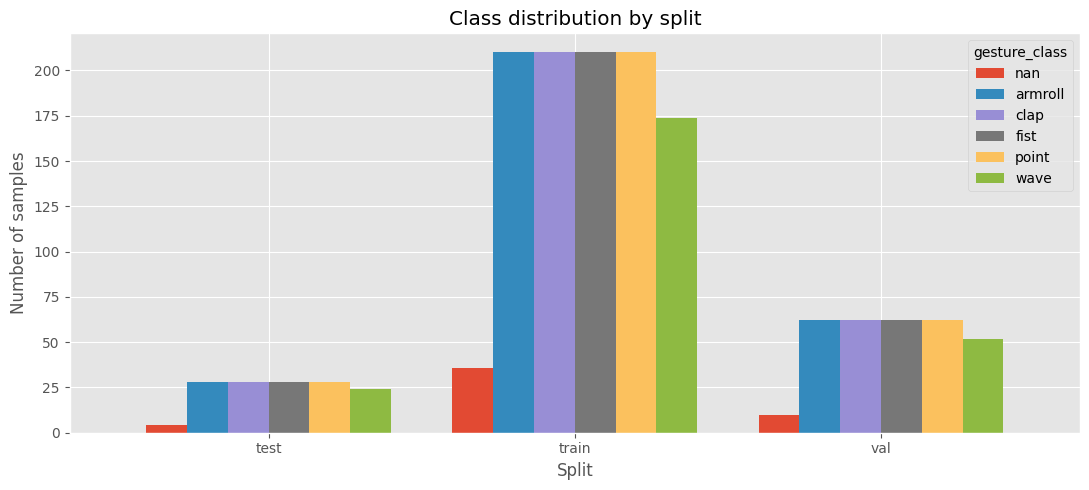

In [11]:
# Distribuzione classi per split
class_dist = (
    df.groupby(["split", "gesture_class"], dropna=False)
      .size()
      .rename("count")
      .reset_index()
)

pivot_class = class_dist.pivot(index="split", columns="gesture_class", values="count").fillna(0).astype(int)
display(pivot_class)

ax = pivot_class.plot(kind="bar", figsize=(11, 5), width=0.8)
ax.set_title("Class distribution by split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

distance,NaN,far,near,normal
split,,,,
test,4,43,49,44
train,36,350,300,364
val,10,107,101,92


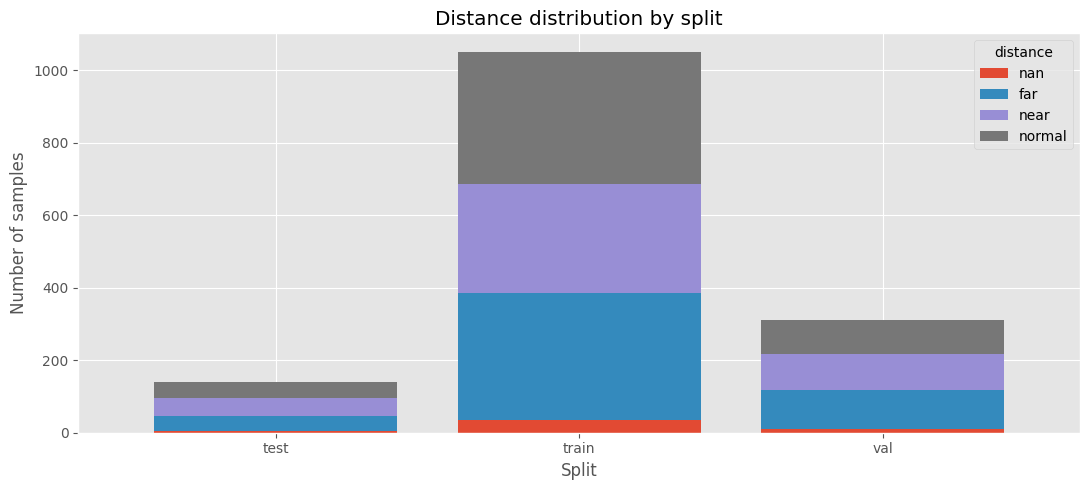

In [12]:
# Distribuzione distanza (near/far/normal/altro)
distance_dist = (
    df.groupby(["split", "distance"], dropna=False)
      .size()
      .rename("count")
      .reset_index()
)

pivot_distance = distance_dist.pivot(index="split", columns="distance", values="count").fillna(0).astype(int)
display(pivot_distance)

ax = pivot_distance.plot(kind="bar", stacked=True, figsize=(11, 5), width=0.8)
ax.set_title("Distance distribution by split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Ispezione rapida dei file con naming non parsabile (se presenti)
bad_parse = df[~df["parse_ok"]].copy()
print("Numero sample con parse non riuscito:", len(bad_parse))
display(bad_parse.head(20))

Numero sample con parse non riuscito: 50


,split,sample_id,h5_exists,bbox_exists,h5_path,bbox_path,subject,distance,gesture_class,sample_index,parse_ok
1014,train,N_wave1,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1015,train,N_wave10,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1016,train,N_wave13,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1017,train,N_wave14,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1018,train,N_wave16,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1019,train,N_wave17,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1020,train,N_wave18,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1021,train,N_wave2,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1022,train,N_wave20,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False
1023,train,N_wave21,True,True,c:\Users\marco\Desktop\Marco\Programmazione\C\...,c:\Users\marco\Desktop\Marco\Programmazione\C\...,NaN,NaN,NaN,NaN,False


## Ispezione schema HDF5

Le strutture HDF5 possono variare per dataset/versione. Qui costruiamo una vista ad albero per capire gruppi/dataset disponibili e identificare i campi eventi (es. `x`, `y`, `t`, `p`).

In [21]:
def h5_tree(path: Path):
    nodes = []
    with h5py.File(path, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                nodes.append({
                    "path": name,
                    "kind": "dataset",
                    "shape": tuple(obj.shape),
                    "dtype": str(obj.dtype),
                })
            else:
                nodes.append({
                    "path": name,
                    "kind": "group",
                    "shape": None,
                    "dtype": None,
                })
        f.visititems(visitor)
    return pd.DataFrame(nodes).sort_values(["kind", "path"])

sample_h5 = Path(df.loc[df["h5_exists"], "h5_path"].iloc[0])
print("Sample for H5 schema inspection:", sample_h5.name)
tree_df = h5_tree(sample_h5)
display(tree_df.head(200))

Sample for H5 schema inspection: D_far_armroll1.h5


,path,kind,shape,dtype
0,data,dataset,"(301, 2, 480, 640)",float32


In [22]:
# Estrazione statistiche eventi su sottoinsieme campioni
# Logica robusta: supporta sia dataset timestamp dedicato sia dataset strutturati con campi (x,y,t,p).
# Supporta anche tensori pre-binnati (es. data con shape [T, C, H, W]) con asse temporale implicito.
TS_CANDIDATES = {"t", "time", "timestamp", "timestamps", "ts"}

def _pick_timestamp_field(dtype_names):
    if not dtype_names:
        return None
    lowered = {name.lower(): name for name in dtype_names}

    # Match esatto preferito
    for key in TS_CANDIDATES:
        if key in lowered:
            return lowered[key]

    # Match parziale come fallback (es. event_timestamp)
    for low_name, orig_name in lowered.items():
        for key in TS_CANDIDATES:
            if key in low_name:
                return orig_name

    return None

def extract_file_event_stats(h5_path: Path):
    info = {
        "event_count": None,
        "t_min": None,
        "t_max": None,
        "duration": None,
        "timestamp_dataset": None,
        "status": "ok",
    }

    try:
        with h5py.File(h5_path, "r") as f:
            candidates = []

            def visitor(name, obj):
                if not isinstance(obj, h5py.Dataset):
                    return

                # Caso 1: dataset strutturato con campo timestamp (tipico event stream).
                if obj.dtype.fields is not None:
                    field_names = list(obj.dtype.fields.keys())
                    ts_field = _pick_timestamp_field(field_names)
                    if ts_field is not None and obj.size > 0:
                        t = np.asarray(obj[ts_field]).reshape(-1)
                        if np.issubdtype(t.dtype, np.number) and t.size > 0:
                            candidates.append({
                                "score": 100 + int(t.size),
                                "event_count": int(obj.shape[0]) if obj.ndim > 0 else int(t.size),
                                "t": t.astype(np.float64, copy=False),
                                "timestamp_dataset": f"{name}:{ts_field}",
                                "status": "ok",
                            })
                        return

                # Caso 2: dataset numerico dedicato ai timestamp.
                last = name.split("/")[-1].lower()
                if last in TS_CANDIDATES and obj.size > 0:
                    t = np.asarray(obj).reshape(-1)
                    if np.issubdtype(t.dtype, np.number):
                        candidates.append({
                            "score": 50 + int(t.size),
                            "event_count": int(t.size),
                            "t": t.astype(np.float64, copy=False),
                            "timestamp_dataset": name,
                            "status": "ok",
                        })
                        return

                # Caso 3: tensore pre-binnato con asse temporale implicito [T, ...].
                # Qui non esiste un timestamp esplicito per evento; usiamo indice temporale dei bin.
                if obj.ndim >= 3 and np.issubdtype(obj.dtype, np.number) and obj.shape[0] > 0:
                    t_bins = int(obj.shape[0])
                    t = np.arange(t_bins, dtype=np.float64)
                    candidates.append({
                        "score": 10 + t_bins,
                        "event_count": t_bins,
                        "t": t,
                        "timestamp_dataset": f"{name}[implicit_time_axis=0]",
                        "status": "ok_implicit_time_axis0",
                    })

            f.visititems(visitor)

            if not candidates:
                info["status"] = "no_timestamp_found"
                return info

            best = max(candidates, key=lambda x: x["score"])
            t = best["t"]

            info["timestamp_dataset"] = best["timestamp_dataset"]
            info["event_count"] = int(best["event_count"])
            info["t_min"] = float(np.min(t))
            info["t_max"] = float(np.max(t))
            info["duration"] = float(np.max(t) - np.min(t))
            info["status"] = best["status"]
            return info

    except Exception as exc:
        info["status"] = f"error: {type(exc).__name__}"
        return info

MAX_PER_SPLIT = 30
rng = random.Random(42)
subset_rows = []
for split in SPLITS:
    split_df = df[df["split"] == split].copy()
    ids = split_df.index.tolist()
    rng.shuffle(ids)
    selected = ids[:MAX_PER_SPLIT] if len(ids) > MAX_PER_SPLIT else ids
    subset_rows.extend(selected)

probe_df = df.loc[subset_rows, ["split", "sample_id", "gesture_class", "distance", "h5_path"]].copy()
stats = []
for _, row in probe_df.iterrows():
    s = extract_file_event_stats(Path(row["h5_path"]))
    stats.append(s)

stats_df = pd.concat([probe_df.reset_index(drop=True), pd.DataFrame(stats)], axis=1)
display(stats_df.head(20))

agg = stats_df.groupby("split").agg(
    samples=("sample_id", "count"),
    valid=("status", lambda x: int(pd.Series(x).astype(str).str.startswith("ok").sum())),
    median_events=("event_count", "median"),
    p90_events=("event_count", lambda x: np.nanpercentile(x.dropna(), 90) if x.dropna().size else np.nan),
    median_duration=("duration", "median"),
    p90_duration=("duration", lambda x: np.nanpercentile(x.dropna(), 90) if x.dropna().size else np.nan),
).reset_index()
display(agg)

,split,sample_id,gesture_class,distance,h5_path,event_count,t_min,t_max,duration,timestamp_dataset,status
0,train,D_near_armroll40,armroll,near,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
1,train,N_normal_armroll39,armroll,normal,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
2,train,D_far_armroll17,armroll,far,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
3,train,N_normal_fist41,fist,normal,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
4,train,D_normal_armroll16,armroll,normal,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
5,train,N_near_armroll44,armroll,near,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
6,train,N_normal_clap30,clap,normal,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
7,train,D_near_clap18,clap,near,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
8,train,N_far_point44,point,far,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0
9,train,D_far_wave29,wave,far,c:\Users\marco\Desktop\Marco\Programmazione\C\...,301,0.0,300.0,300.0,data[implicit_time_axis=0],ok_implicit_time_axis0


,split,samples,valid,median_events,p90_events,median_duration,p90_duration
0,test,30,30,301.0,301.0,300.0,300.0
1,train,30,30,301.0,301.0,300.0,300.0
2,val,30,30,301.0,301.0,300.0,300.0


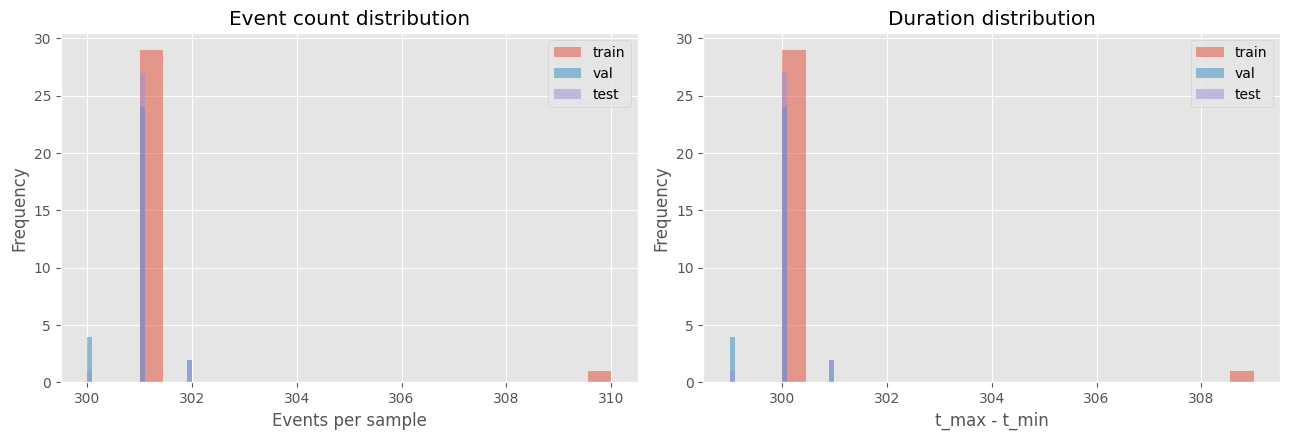

In [23]:
# Visualizzazione distribuzioni eventi/durata (sottoinsieme campionato)
valid_stats = stats_df[stats_df["status"].astype(str).str.startswith("ok")].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for split in SPLITS:
    d = valid_stats[valid_stats["split"] == split]
    if not d.empty:
        axes[0].hist(d["event_count"].dropna(), bins=20, alpha=0.5, label=split)
        axes[1].hist(d["duration"].dropna(), bins=20, alpha=0.5, label=split)

axes[0].set_title("Event count distribution")
axes[0].set_xlabel("Events per sample")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].set_title("Duration distribution")
axes[1].set_xlabel("t_max - t_min")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
# Diagnosi formato temporale: verifica shape H5 e passo temporale implicito
shape_rows = []
for p in df.loc[df["h5_exists"], "h5_path"]:
    with h5py.File(Path(p), "r") as f:
        keys = list(f.keys())
        if "data" not in f:
            shape_rows.append({"h5_path": p, "has_data": False, "shape": None, "dtype": None})
            continue
        d = f["data"]
        shape_rows.append({
            "h5_path": p,
            "has_data": True,
            "shape": tuple(d.shape),
            "dtype": str(d.dtype),
            "ndim": int(d.ndim),
            "T": int(d.shape[0]) if d.ndim >= 1 else None,
        })

shape_df = pd.DataFrame(shape_rows)
display(shape_df.head())

summary_shapes = shape_df.groupby(["shape", "dtype"]).size().reset_index(name="count").sort_values("count", ascending=False)
display(summary_shapes.head(10))

if not shape_df["T"].dropna().empty:
    t_mode = int(shape_df["T"].mode().iloc[0])
    print("T (mode):", t_mode)
    # Se il paper usa finestre da 0.5 s, il passo implicito per bin e': 0.5 / (T-1)
    if t_mode > 1:
        dt_s = 0.5 / (t_mode - 1)
        print(f"dt implicito con durata 0.5s: {dt_s:.8f} s ({dt_s*1e3:.3f} ms)")
        print(f"Campioni temporali in 0.5s: {t_mode}")

,h5_path,has_data,shape,dtype,ndim,T
0,c:\Users\marco\Desktop\Marco\Programmazione\C\...,True,"(301, 2, 480, 640)",float32,4,301
1,c:\Users\marco\Desktop\Marco\Programmazione\C\...,True,"(301, 2, 480, 640)",float32,4,301
2,c:\Users\marco\Desktop\Marco\Programmazione\C\...,True,"(301, 2, 480, 640)",float32,4,301
3,c:\Users\marco\Desktop\Marco\Programmazione\C\...,True,"(301, 2, 480, 640)",float32,4,301
4,c:\Users\marco\Desktop\Marco\Programmazione\C\...,True,"(301, 2, 480, 640)",float32,4,301


,shape,dtype,count
5,"(301, 2, 480, 640)",float32,1367
4,"(300, 2, 480, 640)",float32,73
6,"(302, 2, 480, 640)",float32,54
0,"(100, 2, 480, 640)",float32,1
1,"(179, 2, 480, 640)",float32,1
2,"(209, 2, 480, 640)",float32,1
3,"(266, 2, 480, 640)",float32,1
7,"(310, 2, 480, 640)",float32,1
8,"(2888, 2, 480, 640)",float32,1


T (mode): 301
dt implicito con durata 0.5s: 0.00166667 s (1.667 ms)
Campioni temporali in 0.5s: 301


In [27]:
# Sequenze con T anomalo rispetto al blocco principale ~300
anomalies = shape_df[(shape_df["T"].notna()) & (~shape_df["T"].isin([300, 301, 302]))].copy()
anomalies["sample_name"] = anomalies["h5_path"].apply(lambda p: Path(p).name)

print("Numero sequenze anomale:", len(anomalies))
display(anomalies[["sample_name", "shape", "T"]].sort_values("T"))

Numero sequenze anomale: 6


,sample_name,shape,T
663,N_far_fist22.h5,"(100, 2, 480, 640)",100
543,N_Far_wave33.h5,"(179, 2, 480, 640)",179
110,D_far_point22.h5,"(209, 2, 480, 640)",209
577,N_Normal_wave50.h5,"(266, 2, 480, 640)",266
727,N_far_wave39.h5,"(310, 2, 480, 640)",310
699,N_far_point23.h5,"(2888, 2, 480, 640)",2888


## Protocollo proposto (versione iniziale)

Questa sezione formalizza le scelte iniziali da usare nelle fasi B/C/D. I valori sono deliberatamente conservativi e andranno raffinati dopo i primi baseline run.

In [28]:
protocol = {
    "dataset": {
        "name": "EB-HandGesture",
        "splits": SPLITS,
        "classes": sorted([c for c in df["gesture_class"].dropna().unique().tolist()]),
        "distance_labels": sorted([d for d in df["distance"].dropna().unique().tolist()]),
        "pairing_required": True,
    },
    "preprocessing": {
        "bbox_usage": "enabled_if_consistent",
        "temporal_binning": {
            "strategy": "fixed_num_bins",
            "num_bins_candidates": [8, 12, 16, 24],
        },
        "spatial_resolution": {
            "strategy": "native_or_downsample",
            "candidates": ["native", [128, 128], [96, 96]],
        },
        "normalization": "timestamp_to_relative",
    },
    "training_eval": {
        "primary_metric": "top1_accuracy",
        "secondary_metrics": ["macro_f1", "latency_ms", "spike_activity"],
        "reproducibility": {
            "seed": 42,
            "num_repeats": 3,
        },
    },
    "hardware_awareness": {
        "target": "SynSense Speck",
        "framework": "sinabs",
        "note": "Verificare compatibilita layer e vincoli hardware gia dalla baseline",
    },
}

print(json.dumps(protocol, indent=2))

{
  "dataset": {
    "name": "EB-HandGesture",
    "splits": [
      "train",
      "val",
      "test"
    ],
    "classes": [
      "armroll",
      "clap",
      "fist",
      "point",
      "wave"
    ],
    "distance_labels": [
      "far",
      "near",
      "normal"
    ],
    "pairing_required": true
  },
  "preprocessing": {
    "bbox_usage": "enabled_if_consistent",
    "temporal_binning": {
      "strategy": "fixed_num_bins",
      "num_bins_candidates": [
        8,
        12,
        16,
        24
      ]
    },
    "spatial_resolution": {
      "strategy": "native_or_downsample",
      "candidates": [
        "native",
        [
          128,
          128
        ],
        [
          96,
          96
        ]
      ]
    },
    "normalization": "timestamp_to_relative"
  },
  "training_eval": {
    "primary_metric": "top1_accuracy",
    "secondary_metrics": [
      "macro_f1",
      "latency_ms",
      "spike_activity"
    ],
    "reproducibility": {
      "seed": 

In [29]:
# Export del report Fase A in CSV/JSON (opzionale ma utile per tracciabilita')
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)

summary_df.to_csv(REPORT_DIR / "phaseA_inventory_summary.csv", index=False)
class_dist.to_csv(REPORT_DIR / "phaseA_class_distribution.csv", index=False)
distance_dist.to_csv(REPORT_DIR / "phaseA_distance_distribution.csv", index=False)
stats_df.to_csv(REPORT_DIR / "phaseA_event_probe_stats.csv", index=False)

with open(REPORT_DIR / "phaseA_protocol_v1.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, indent=2)

print("Report salvati in:", REPORT_DIR)

Report salvati in: c:\Users\marco\Desktop\Marco\Programmazione\C\EsPoli\MLIA\EB-HandGesture\reports


## Checklist di uscita Fase A

- Integrita dataset verificata (pairing e naming).
- Distribuzioni split/classe/distanza quantificate.
- Schema HDF5 ispezionato e campi eventi identificati.
- Prime statistiche temporali/eventi stimate.
- Protocollo v1 formalizzato ed esportato.

Con questa base puoi passare alla Fase B con una baseline SNN riproducibile e metriche coerenti con il target neuromorfico.